
# LEI-Local Sensitivity — Metrics Analysis Notebook

Este notebook analisa as métricas geradas pelo script **LEI-Local (Sensibilidade)**,
a partir do arquivo `metrics_per_gen.csv`, `best_delta_z.npy` e `config.json` salvos em um diretório de experimento.

Preencha a variável `RUN_DIR` abaixo com o caminho da pasta de um run específico
(ex.: `outputs_lei_local_sensitivity/2025-12-10T17-30-00`).


In [6]:

# ======================
# 1. Imports e carregamento
# ======================
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

# Deixa os gráficos mais bonitinhos
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

# Caminho para a pasta de um experimento específico
# >>>>> AJUSTE AQUI <<<<<
RUN_DIR = "/scratch/samiramalaquias/lei_local/src/outputs_lei_local_sensitivity/2025-12-10T21-04-41"


csv_path = os.path.join(RUN_DIR, "metrics_per_gen.csv")
delta_z_path = os.path.join(RUN_DIR, "best_delta_z.npy")
config_path = os.path.join(RUN_DIR, "config.json")
final_pop_path = os.path.join(RUN_DIR, "final_population.pt")
best_final_img_path = os.path.join(RUN_DIR, "best_final.png")

# Carrega CSV de métricas
df = pd.read_csv(csv_path)

# Carrega delta_z do melhor indivíduo final
delta_z = np.load(delta_z_path)  # shape [4,8,8]

# Carrega config para saber p0, classe alvo, etc.
with open(config_path, "r") as f:
    config = json.load(f)

p0 = config["P0"]
target_class_idx = config["TARGET_CLASS"]
target_class_name = config["TARGET_CLASS_NAME"]

print("p0 =", p0)
print("Classe alvo:", target_class_idx, target_class_name)
print("N linhas de métricas:", len(df))


p0 = 0.9942446351051331
Classe alvo: 2 bird
N linhas de métricas: 87500


## 2. Visão geral das métricas

In [7]:

df.head()


,generation,index,fitness,p0,p_target,delta_p,dist_lat
0,1,0,-31.999710,0.994245,0.994246,0.000002,31.817919
1,1,1,-32.374512,0.994245,0.994182,0.000062,32.158703
2,1,2,-32.814724,0.994245,0.994149,0.000095,32.558926
3,1,3,-32.357761,0.994245,0.994156,0.000089,32.143501
4,1,4,-31.772085,0.994245,0.994110,0.000134,31.611109


In [8]:

# Resumo estatístico geral
df.describe()


,generation,index,fitness,p0,p_target,delta_p,dist_lat
count,87500.000000,87500.000000,87500.000000,87500.000000,87500.000000,87500.000000,87500.000000
mean,175.500000,124.500000,-39.548666,0.994245,0.994121,0.000125,38.680718
std,101.036462,72.168619,13.074020,0.000000,0.000187,0.000186,11.885541
min,1.000000,0.000000,-88.819115,0.994245,0.952889,0.000000,23.874994
25%,88.000000,62.000000,-48.941752,0.994245,0.994100,0.000064,28.032498
50%,175.500000,124.500000,-37.052723,0.994245,0.994159,0.000086,36.411636
75%,263.000000,187.000000,-27.835645,0.994245,0.994181,0.000144,47.219846
max,350.000000,249.000000,-23.262424,0.994245,0.994360,0.041356,83.473373


In [9]:

# Quantas gerações e quantos indivíduos por geração?
num_gens = df["generation"].nunique()
num_inds = df["index"].nunique()
print("Número de gerações:", num_gens)
print("Número de indivíduos por geração (esperado):", num_inds)


Número de gerações: 350
Número de indivíduos por geração (esperado): 250


## 3. Evolução da sensibilidade ao longo das gerações

In [10]:

# Agregação por geração: média/máximo de delta_p, média de dist_lat, máximo de fitness
gen_stats = df.groupby("generation").agg({
    "delta_p": ["mean", "max"],
    "dist_lat": "mean",
    "fitness": "max"
})
gen_stats.columns = ["delta_p_mean", "delta_p_max", "dist_lat_mean", "fitness_max"]
gen_stats.head()


,delta_p_mean,delta_p_max,dist_lat_mean,fitness_max
generation,,,,
1,0.000063,0.000213,32.001557,-31.085476
2,0.000104,0.000436,40.046706,-23.583302
3,0.000139,0.000616,44.556929,-23.583302
4,0.000156,0.001895,46.619362,-23.583302
5,0.000165,0.001488,47.948957,-23.583302


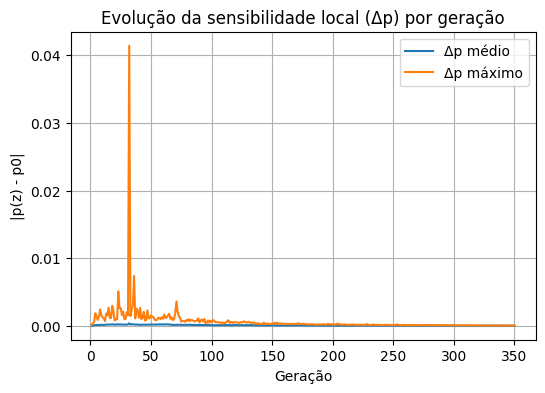

In [11]:

# Curva da mudança média e máxima de probabilidade
fig, ax = plt.subplots()
ax.plot(gen_stats.index, gen_stats["delta_p_mean"], label="Δp médio")
ax.plot(gen_stats.index, gen_stats["delta_p_max"], label="Δp máximo")
ax.set_xlabel("Geração")
ax.set_ylabel("|p(z) - p0|")
ax.set_title("Evolução da sensibilidade local (Δp) por geração")
ax.legend()
plt.show()


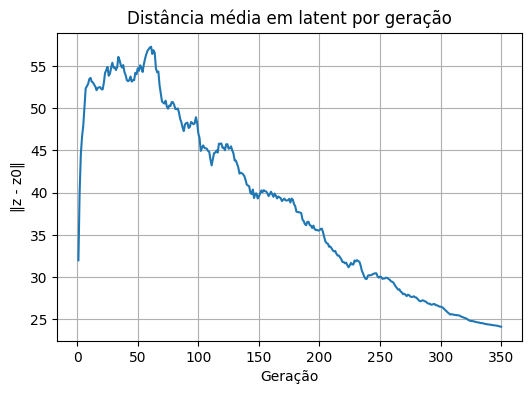

In [12]:

# Distância média em latent ao longo das gerações
fig, ax = plt.subplots()
ax.plot(gen_stats.index, gen_stats["dist_lat_mean"])
ax.set_xlabel("Geração")
ax.set_ylabel("‖z - z0‖")
ax.set_title("Distância média em latent por geração")
plt.show()


## 4. Trade-off distância vs mudança de probabilidade

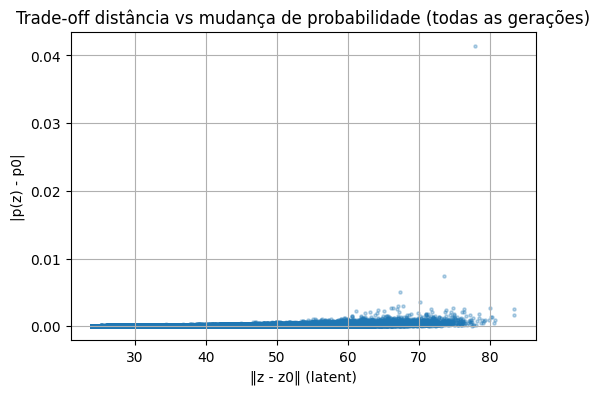

In [13]:

# Scatter dist_lat vs delta_p (todas as gerações)
fig, ax = plt.subplots()
ax.scatter(df["dist_lat"], df["delta_p"], alpha=0.3, s=5)
ax.set_xlabel("‖z - z0‖ (latent)")
ax.set_ylabel("|p(z) - p0|")
ax.set_title("Trade-off distância vs mudança de probabilidade (todas as gerações)")
plt.show()


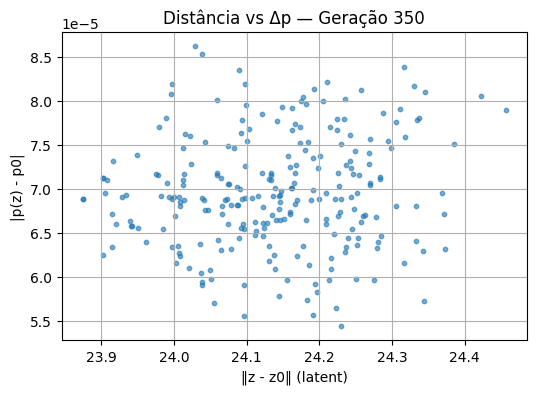

In [14]:

# Focar na última geração
last_gen = df["generation"].max()
df_last = df[df["generation"] == last_gen]

fig, ax = plt.subplots()
ax.scatter(df_last["dist_lat"], df_last["delta_p"], alpha=0.6, s=10)
ax.set_xlabel("‖z - z0‖ (latent)")
ax.set_ylabel("|p(z) - p0|")
ax.set_title(f"Distância vs Δp — Geração {last_gen}")
plt.show()


In [15]:

# Identificar contraexemplos locais "bons": grande Δp e pequena distância
max_dist = 3.0   # ajuste conforme seu TRUST_REGION_RADIUS
min_delta_p = 0.3

good_ce = df_last[(df_last["dist_lat"] <= max_dist) & (df_last["delta_p"] >= min_delta_p)]
good_ce_sorted = good_ce.sort_values("delta_p", ascending=False)
good_ce_sorted.head(10)


,generation,index,fitness,p0,p_target,delta_p,dist_lat


## 5. Distribuição das probabilidades da classe alvo

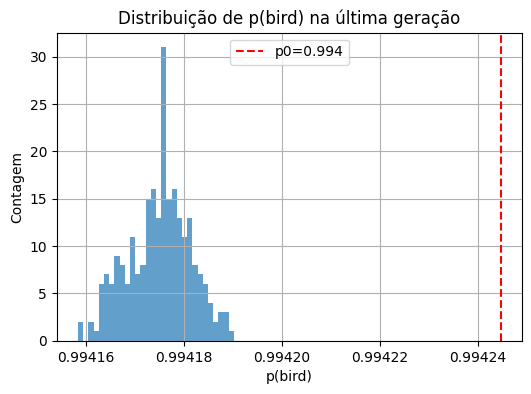

In [16]:

# Distribuição de p_target na última geração
fig, ax = plt.subplots()
ax.hist(df_last["p_target"], bins=30, alpha=0.7)
ax.axvline(p0, color="red", linestyle="--", label=f"p0={p0:.3f}")
ax.set_xlabel(f"p({target_class_name})")
ax.set_ylabel("Contagem")
ax.set_title(f"Distribuição de p({target_class_name}) na última geração")
ax.legend()
plt.show()


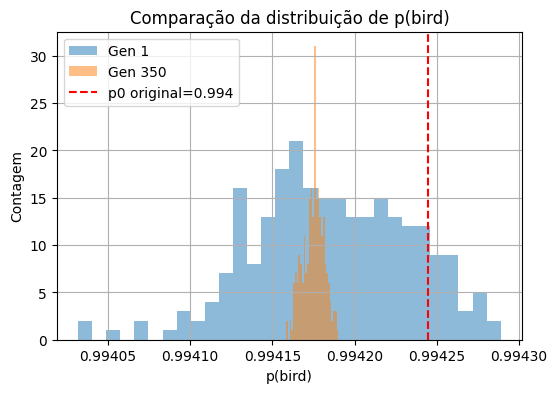

In [17]:

# Comparação entre primeira e última geração
first_gen = df["generation"].min()
df_first = df[df["generation"] == first_gen]

fig, ax = plt.subplots()
ax.hist(df_first["p_target"], bins=30, alpha=0.5, label=f"Gen {first_gen}")
ax.hist(df_last["p_target"], bins=30, alpha=0.5, label=f"Gen {last_gen}")
ax.axvline(p0, color="red", linestyle="--", label=f"p0 original={p0:.3f}")
ax.set_xlabel(f"p({target_class_name})")
ax.set_ylabel("Contagem")
ax.set_title(f"Comparação da distribuição de p({target_class_name})")
ax.legend()
plt.show()


## 6. Direção latente do melhor contraexemplo (Δz)

In [18]:

# delta_z tem shape [4,8,8]
delta_flat = delta_z.flatten()   # shape [256]
abs_delta = np.abs(delta_flat)

# Top-k dimensões que mais mudaram em módulo
k = 20
topk_idx = np.argsort(-abs_delta)[:k]
topk_vals = delta_flat[topk_idx]

topk_df = pd.DataFrame({
    "latent_dim": topk_idx,
    "delta_z": topk_vals,
    "abs_delta_z": np.abs(topk_vals)
}).sort_values("abs_delta_z", ascending=False)

topk_df


,latent_dim,delta_z,abs_delta_z
0,3434,1.499343,1.499343
1,1006,1.430672,1.430672
2,2872,1.341586,1.341586
3,2971,-1.318650,1.318650
4,1904,-1.285563,1.285563
5,2816,1.280294,1.280294
6,330,1.270906,1.270906
7,3750,1.255465,1.255465
8,313,1.233076,1.233076
9,3627,-1.226136,1.226136


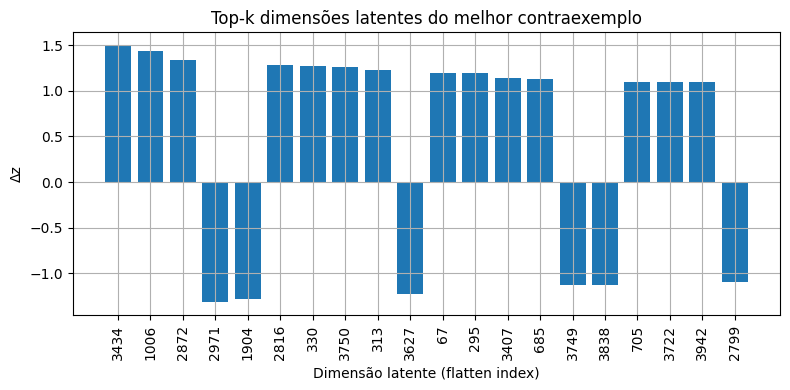

In [19]:

# Barplot das k dimensões mais importantes
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(k), topk_df["delta_z"])
ax.set_xticks(range(k))
ax.set_xticklabels(topk_df["latent_dim"], rotation=90)
ax.set_xlabel("Dimensão latente (flatten index)")
ax.set_ylabel("Δz")
ax.set_title("Top-k dimensões latentes do melhor contraexemplo")
plt.tight_layout()
plt.show()


## 7. Visualização dos melhores contraexemplos locais (grid)

In [20]:

import torch

# Carrega população final
pop_final = torch.load(final_pop_path, map_location="cpu")  # lista de tensores [4,8,8]

# Função utilitária para reconstruir um batch de latentes usando o mesmo VAE do treino
from diffusers import AutoencoderKL

vae_path = config.get("VAE_MODEL", "stabilityai/sd-vae-ft-ema")
DEVICE_VIS = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae_vis = AutoencoderKL.from_pretrained(vae_path).to(DEVICE_VIS)
vae_vis.eval()

def latent_batch_to_pil_vis(batch_z: torch.Tensor) -> list[Image.Image]:
    with torch.no_grad():
        recon = vae_vis.decode(batch_z.to(DEVICE_VIS)).sample  # [B,3,32,32]
    recon = (recon.clamp(-1, 1) + 1.0) / 2.0
    recon_cpu = recon.cpu()
    pil_list = []
    to_pil_local = transforms.ToPILImage()
    for i in range(recon_cpu.shape[0]):
        img_rgb = recon_cpu[i]
        pil_32 = to_pil_local(img_rgb)
        pil = pil_32.resize((224, 224))
        pil_list.append(pil)
    return pil_list


/scratch/samiramalaquias/venv_samis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


In [21]:

# Selecionar top-N contraexemplos locais (Δp alto, distância baixa) na última geração
N_TOP = 9
max_dist = 3.0
min_delta_p = 0.3

df_last = df[df["generation"] == df["generation"].max()]
df_last_ce = df_last[df_last["dist_lat"] <= max_dist]
df_last_ce = df_last_ce.sort_values("delta_p", ascending=False)
top_ce = df_last_ce.head(N_TOP)
top_ce


,generation,index,fitness,p0,p_target,delta_p,dist_lat


In [22]:

# Se você tiver a imagem original salva, pode carregá-la.
# Caso contrário, pule a parte de exibir a original.
try:
    x0_pil = Image.open(config.get("INPUT_IMAGE_PATH", "")).convert("RGB")
except Exception:
    x0_pil = None

def show_top_counterexamples(pop_final, top_ce_df, x0_pil=None, n_cols=5):
    n = len(top_ce_df)
    if n == 0:
        print("Nenhum contraexemplo encontrado com os critérios definidos.")
        return

    n_cols = min(n_cols, n)
    n_rows = int(np.ceil(n / n_cols))

    W, H = 224, 224
    extra_rows = 1 if x0_pil is not None else 0
    grid = Image.new("RGB", (n_cols * W, (n_rows + extra_rows) * H))

    # linha 0: imagem original repetida (se existir)
    if x0_pil is not None:
        x0_resized = x0_pil.resize((W, H))
        for c in range(n_cols):
            grid.paste(x0_resized, (c * W, 0))

    # linhas subsequentes: contraexemplos
    import math
    idx_list = list(top_ce_df["index"].astype(int))
    batch_z = torch.stack([pop_final[i] for i in idx_list], dim=0)
    pil_imgs = latent_batch_to_pil_vis(batch_z)

    for j, pil in enumerate(pil_imgs):
        r = j // n_cols
        c = j % n_cols
        row_offset = extra_rows
        grid.paste(pil.resize((W, H)), (c * W, (r + row_offset) * H))

    display(grid)

show_top_counterexamples(pop_final, top_ce, x0_pil=x0_pil, n_cols=5)


Nenhum contraexemplo encontrado com os critérios definidos.
